In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# Average plane Z positions
Z_DC31_X = -(10.3+7.3-1.7-4.7)/4.0
Z_DC31_Y = -(4.3+1.3-7.7-10.7)/4.0
Z_DC32_X = -(4.5+1.5)/2.0
Z_DC32_Y = -(-1.5-4.5)/2.0

# Detector Z positions
Z_DC31 = -271.5 # mm
Z_DC32 = 787.97 # mm
Z_SRPPAC = 0.0 # mm

spark = SparkSession.builder.master("local[10]").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

df = spark.read.parquet("parquet/run1024_joined.parquet")
df.show(5)

+---------+------------------+------------------+-------------------+-------------------+------------------+------------------+
|hbfNumber|          sr_pos_x|          sr_pos_y|             dc31_x|             dc31_y|            dc32_x|            dc32_y|
+---------+------------------+------------------+-------------------+-------------------+------------------+------------------+
| 10957674| 8.415282213687895|19.440814270973206|  6.216108322143555| 11.478063583374023| 7.097080707550049|10.142938613891602|
| 10950066| 2.964650350809097| 14.73943547487259| 0.9986393451690674|  7.481853485107422|0.5895429253578186| 3.622849941253662|
| 10950153| 4.147695398330688| 5.562447998523712| 1.7636970281600952|-1.9813731908798218|1.9994856119155884|-4.471199035644531|
| 10981423| 3.335964488983154|2.3307471442222596| 0.9232541918754578| -5.785601615905762|3.0873308181762695|-6.160952568054199|
| 10981735|2.2937431216239927|19.384192719459534|-0.5194137692451477| 11.304081916809082| 3.351223945617

In [18]:
L2X = Z_DC32 - Z_SRPPAC + Z_DC32_X
L2Y = Z_DC32 - Z_SRPPAC + Z_DC32_Y
L1X = Z_DC31 - Z_SRPPAC + Z_DC31_X
L1Y = Z_DC31 - Z_SRPPAC + Z_DC31_Y

df_chk = df.withColumn("interp_mwdc_x", F.expr(f"(dc31_x * {L2X} - dc32_x * {L1X})/(ABS({L1X}) + ABS({L2X}))")) \
           .withColumn("interp_mwdc_y", F.expr(f"(dc31_y * {L2Y} - dc32_y * {L1Y})/(ABS({L1Y}) + ABS({L2Y}))"))
df_chk.show(5)

+---------+------------------+------------------+-------------------+-------------------+------------------+------------------+------------------+------------------+
|hbfNumber|          sr_pos_x|          sr_pos_y|             dc31_x|             dc31_y|            dc32_x|            dc32_y|     interp_mwdc_x|     interp_mwdc_y|
+---------+------------------+------------------+-------------------+-------------------+------------------+------------------+------------------+------------------+
| 10957674| 8.415282213687895|19.440814270973206|  6.216108322143555| 11.478063583374023| 7.097080707550049|10.142938613891602| 6.444237812563374|11.139892928760815|
| 10950066| 2.964650350809097| 14.73943547487259| 0.9986393451690674|  7.481853485107422|0.5895429253578186| 3.622849941253662|0.8927030419090625| 6.504415578987204|
| 10950153| 4.147695398330688| 5.562447998523712| 1.7636970281600952|-1.9813731908798218|1.9994856119155884|-4.471199035644531|1.8247549345712386|-2.612015306818508|
| 10

from hist.sparkHist2d import Hist2D
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt

h = Hist2D(df_chk, ["interp_mwdc_x", "charge0_x"], [200,200], [[-15,15], [0,50]], norm=LogNorm(), interpolation='none')
plt.xlabel("X(mm)")
plt.ylabel("Q0(ns)")
plt.show()
h = Hist2D(df_chk, ["interp_mwdc_x", "charge1_x"], [200,200], [[-15,15], [0,50]], norm=LogNorm(), interpolation='none')
plt.xlabel("X(mm)")
plt.ylabel("Q1(ns)")
plt.show()

d = df_chk.withColumn("q0-q1",F.expr("charge0_x - charge1_x"))
h = Hist2D(d, ["interp_mwdc_x", "q0-q1"], [200,200], [[-15,15], [0,20]], norm=LogNorm(), interpolation='none')
plt.xlabel("X(mm)")
plt.ylabel("Q0-Q1(ns)")
plt.show()

Statistics:
[[   0.    5.    0.]
 [   0. 2944.    0.]
 [   0.    0.    0.]]


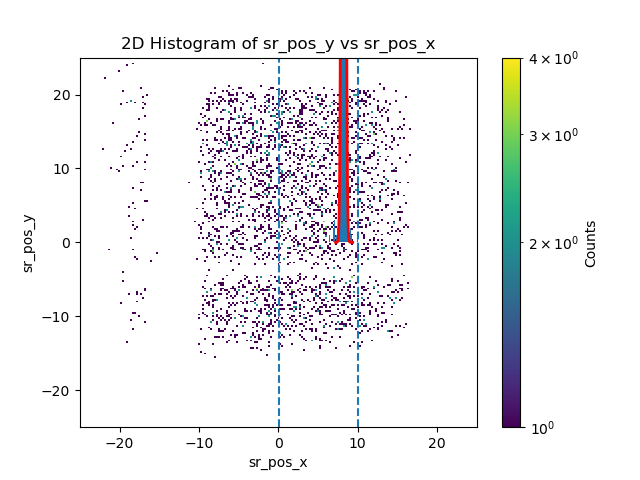

Statistics:
[[   0.    6.    0.]
 [   0. 3020.    0.]
 [   0.    5.    0.]]


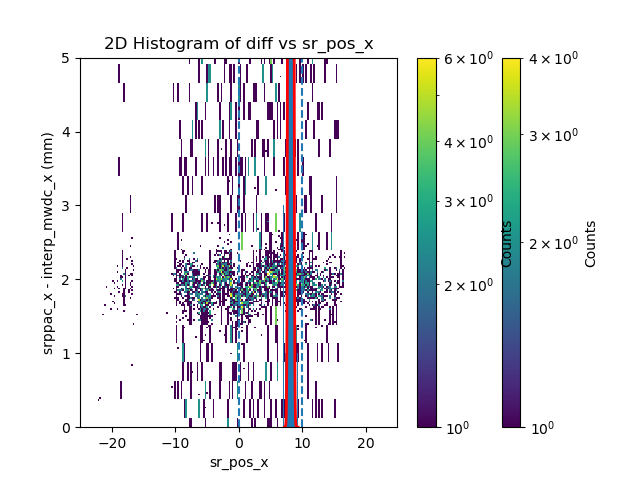

Statistics:
[[0.000e+00 6.000e+00 2.000e+00]
 [0.000e+00 2.953e+03 2.000e+00]
 [0.000e+00 1.000e+00 0.000e+00]]


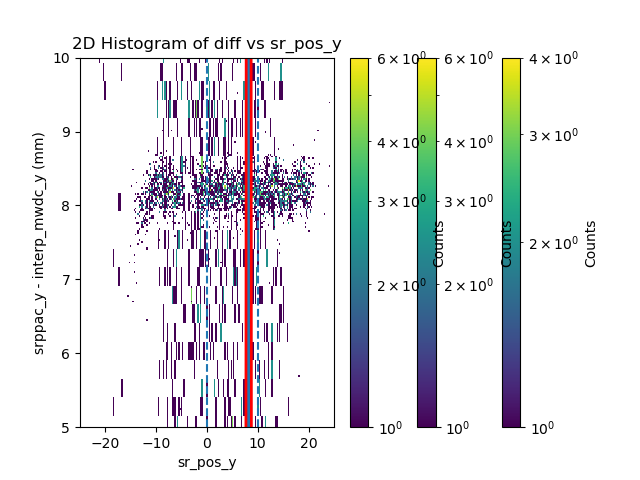

Total entries: 3036, Underflow: 5, Inside: 3017, Overflow: 14


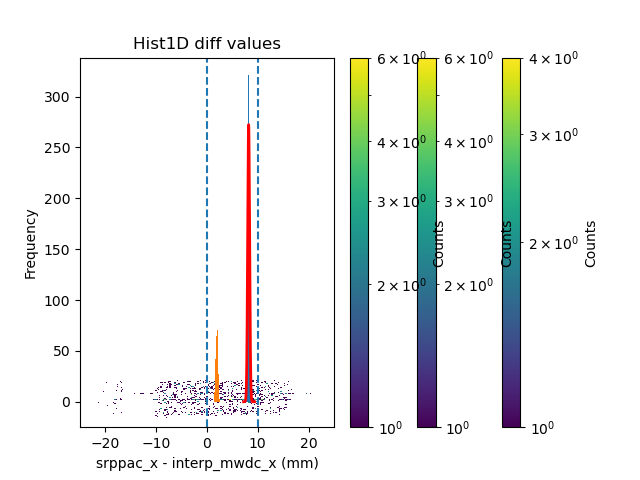

Total entries: 2975, Underflow: 11, Inside: 2956, Overflow: 8


Text(0.5, 23.52222222222222, 'srppac_y - interp_mwdc_y (mm)')

In [19]:
from hist.sparkHist2d import Hist2D
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt

h = Hist2D(df_chk, ["sr_pos_x", "sr_pos_y"], [200,200], [[-25,25], [-25,25]], norm=LogNorm(), interpolation='none')
plt.show()
h = Hist2D(df_chk.withColumn("diff", F.expr("sr_pos_x - interp_mwdc_x")), ["sr_pos_x", "diff"], [200,200], [[-25,25], [0,5]], norm=LogNorm(), interpolation='none')
plt.ylabel("srppac_x - interp_mwdc_x (mm)")
plt.show()
h = Hist2D(df_chk.withColumn("diff", F.expr("sr_pos_y - interp_mwdc_y")), ["sr_pos_y", "diff"], [200,200], [[-25,25], [5,10]], norm=LogNorm(), interpolation='none')
plt.ylabel("srppac_y - interp_mwdc_y (mm)")
plt.show()
from hist.sparkHist1d import Hist1D
h = Hist1D(df_chk.withColumn("diff", F.expr("sr_pos_x - interp_mwdc_x")), "diff", 200, [0,3])
plt.xlabel("srppac_x - interp_mwdc_x (mm)")
plt.show()
h = Hist1D(df_chk.withColumn("diff", F.expr("sr_pos_y - interp_mwdc_y")), "diff", 200, [7,10])
plt.xlabel("srppac_y - interp_mwdc_y (mm)")

Total entries: 3036, Underflow: 5, Inside: 3031, Overflow: 0


Output()

Output()

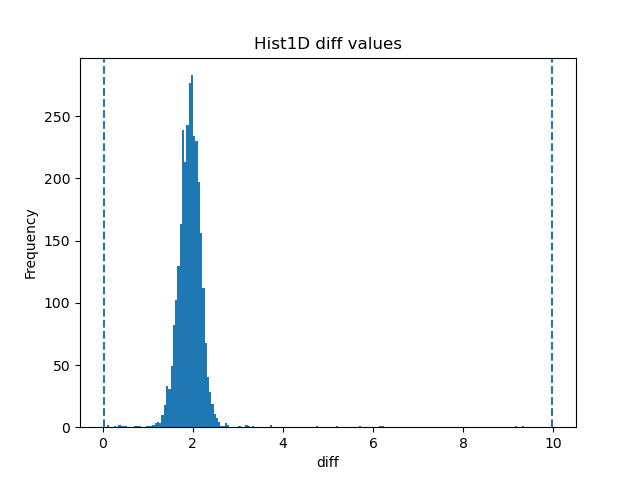

In [20]:
%matplotlib widget

plt.clf()

from hist.sparkHist1d import Hist1D
Hist1D(df_chk.withColumn("diff", F.expr("sr_pos_x - interp_mwdc_x")), "diff", 200, [0,10])

from matplotlib import pyplot as plt
from hist.fitHist1d import FitHist1DGauss
FitHist1DGauss()
plt.show()



Total entries: 2964, Underflow: 0, Inside: 2956, Overflow: 8


Output()

Output()

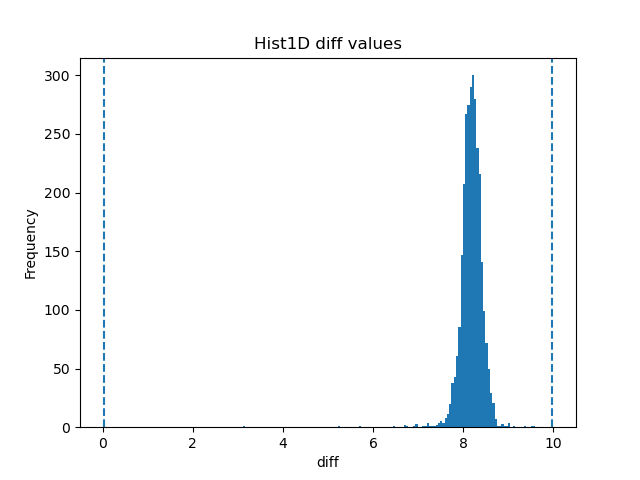

In [ ]:
plt.clf()

from hist.sparkHist1d import Hist1D
Hist1D(df_chk.withColumn("diff", F.expr("sr_pos_x - interp_mwdc_x")), "diff", 200, [0,10])

from matplotlib import pyplot as plt
from hist.fitHist1d import FitHist1DGauss
FitHist1DGauss()
plt.show()